# 10 · Are meningeal nuclei really more elongated? Random examples and statistics

Notebook 09 showed *typical* windows – still a choice. Here the evidence is built so that it does not
depend on choices:

1. **Statistics with the section as the unit.** Every section has meninges, so all sections are used
   (lesion and control, 17 sections from 6 animals), each compared with its *own* parenchyma (distal in
   lesion sections, GM / WM in control sections); replicate slides are averaged. Tests: sign test and
   Wilcoxon over sections, and a **hierarchical bootstrap** (resample animals, then sections) for a 95 %
   confidence interval that respects that sections from one animal are not independent.
2. **Robustness checks.** The effect has to survive other cut-offs, the continuous median eccentricity,
   well-segmented nuclei only (solidity ≥ 0.9: merged nuclei look elongated), size-matched nuclei,
   Pu.1⁻ and Pu.1⁺ separately, and an **edge-artefact control** – parenchyma 20–80 µm under the surface
   instead of distal tissue (nuclei at a cut edge can be squashed or partly cut).
3. **Depth profile.** Elongated share against depth below the surface, per slide – no compartment
   boundary involved.
4. **Random galleries.** Windows drawn at random (fixed seed) among surface-meninges nuclei and, for
   comparison, distal nuclei – nothing selected on elongation – with a tally of how many random meninges
   windows beat their slide's parenchyma.

Meninges here = surface meninges (≤ 80 µm deep; flaps / roots excluded). As in notebook 09, *meninges
is a place*: meningeal cells plus infiltrate.

In [1]:
import os, json, warnings
from pathlib import Path
warnings.filterwarnings("ignore")
os.chdir(Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd())
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from IPython.display import Image, display, Markdown
%config InlineBackend.figure_format = 'jpeg'   # image-heavy notebooks: keep files small
plt.rcParams["figure.dpi"] = 80
from lesionseg import report as R
pd.set_option("display.width", 220); pd.set_option("display.max_columns", 40); pd.set_option("display.max_rows", 120)
RUN_DIR = "outputs/sdata"
runs = R.load_runs(RUN_DIR)
print("scenes:", [r.name for r in runs])

from lesionseg import expression as E, morphology as M
df = E.expression_table(runs)
rob = M.robustness_table(df)
rob.round(4)

scenes: ['CML_1 scene 0', 'CML_2_rescan scene 0', 'CML_metal scene 0', 'CML_metal scene 1']


,check,sections,animals,median_delta,mean_delta,ci95_low,ci95_high,sections_higher,sign_test_p,wilcoxon_p
0,"elongated share (ecc ≥ 0.85), all nuclei",17,6,11.7371,13.3125,9.6605,16.8948,16,0.0003,0.0000
1,"elongated share, ecc ≥ 0.80",17,6,14.2609,15.3353,11.2864,19.0323,16,0.0003,0.0000
2,"elongated share, ecc ≥ 0.90",17,6,8.9357,9.4541,6.3488,12.6541,16,0.0003,0.0000
3,median eccentricity (×100),17,6,6.4436,6.4628,4.7780,8.0414,17,0.0000,0.0000
4,well-segmented nuclei only (solidity ≥ 0.9),17,6,12.1752,11.9356,9.0136,14.7022,16,0.0003,0.0000
5,size-matched nuclei (15–45 µm²),17,6,13.4207,14.4681,10.5975,18.3808,16,0.0003,0.0000
6,Pu.1⁻ nuclei only,17,6,10.0365,14.1895,9.2779,19.7113,16,0.0003,0.0000
7,Pu.1⁺ nuclei only,16,6,13.4652,12.3144,8.1736,16.3628,14,0.0042,0.0002
8,vs parenchyma 20–80 µm under the surface (edge...,17,6,13.4222,12.2274,9.2931,15.0270,16,0.0003,0.0000


## Effect under every check (mean Δ meninges − parenchyma, 95 % hierarchical-bootstrap CI)

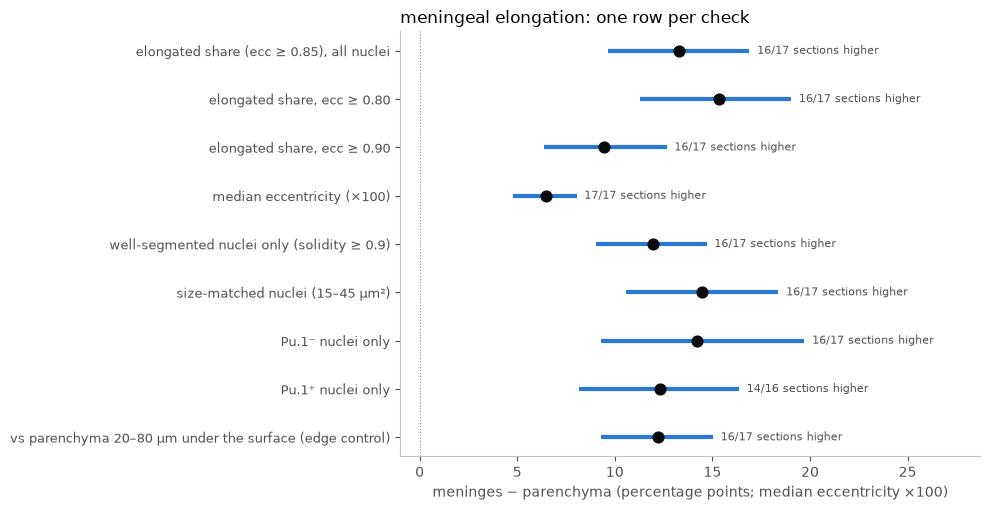

In [2]:
fig, ax = plt.subplots(figsize=(10, 5.2))
y = np.arange(len(rob))[::-1]
ax.hlines(y, rob.ci95_low, rob.ci95_high, color="#2a78d6", lw=3)
ax.scatter(rob.mean_delta, y, s=60, color="#0b0b0b", zorder=3)
for yi, r in zip(y, rob.itertuples()):
    ax.text(r.ci95_high + 0.4, yi, f"{r.sections_higher}/{r.sections} sections higher", va="center", fontsize=8, color="#52514e")
ax.axvline(0, color="#898781", lw=0.8, ls=":")
ax.set_yticks(y, rob.check, fontsize=9)
ax.set_xlabel("meninges − parenchyma (percentage points; median eccentricity ×100)")
ax.set_title("meningeal elongation: one row per check", loc="left")
ax.set_xlim(left=min(-1, rob.ci95_low.min() - 1), right=rob.ci95_high.max() + 9)
plt.tight_layout(); plt.show()

## Per section: meninges vs the section's own parenchyma (replicate slides averaged)

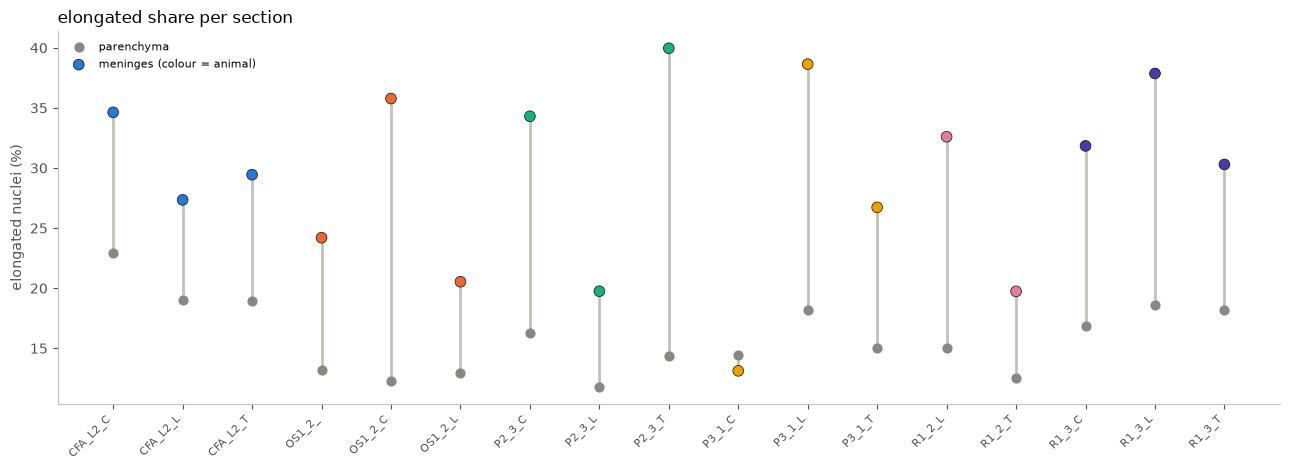

group,section,meninges,parenchyma,delta,animal
0,CFA_L2_C,34.63,22.93,11.70,CFA_L2
1,CFA_L2_L,27.35,19.01,8.34,CFA_L2
2,CFA_L2_T,29.44,18.92,10.53,CFA_L2
3,OS1_2_,24.20,13.18,11.02,OS1_2
4,OS1_2_C,35.78,12.28,23.49,OS1_2
5,OS1_2_L,20.54,12.91,7.64,OS1_2
6,P2_3_C,34.30,16.28,18.02,P2_3
7,P2_3_L,19.75,11.77,7.97,P2_3
8,P2_3_T,39.96,14.32,25.64,P2_3
9,P3_1_C,13.13,14.47,-1.34,P3_1


In [3]:
per = M.meninges_effect(df).sort_values(["animal", "section"])
animals = sorted(per.animal.unique())
acol = dict(zip(animals, ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#4a3aa7"]))
fig, ax = plt.subplots(figsize=(13, 4.8))
x = np.arange(len(per))
for xi, r in zip(x, per.itertuples()):
    ax.plot([xi, xi], [r.parenchyma, r.meninges], color="#c3c2b7", lw=2, zorder=1)
ax.scatter(x, per.parenchyma, s=40, color="#898781", label="parenchyma", zorder=2)
ax.scatter(x, per.meninges, s=60, color=[acol[a] for a in per.animal], edgecolors="#0b0b0b", linewidths=0.5,
           label="meninges (colour = animal)", zorder=3)
ax.set_xticks(x, per.section, rotation=45, ha="right", fontsize=8)
ax.set_ylabel("elongated nuclei (%)"); ax.set_title("elongated share per section", loc="left")
ax.legend(fontsize=8, frameon=False)
plt.tight_layout(); plt.show()
display(per.round(2))

## Depth profile: elongated share against depth below the surface

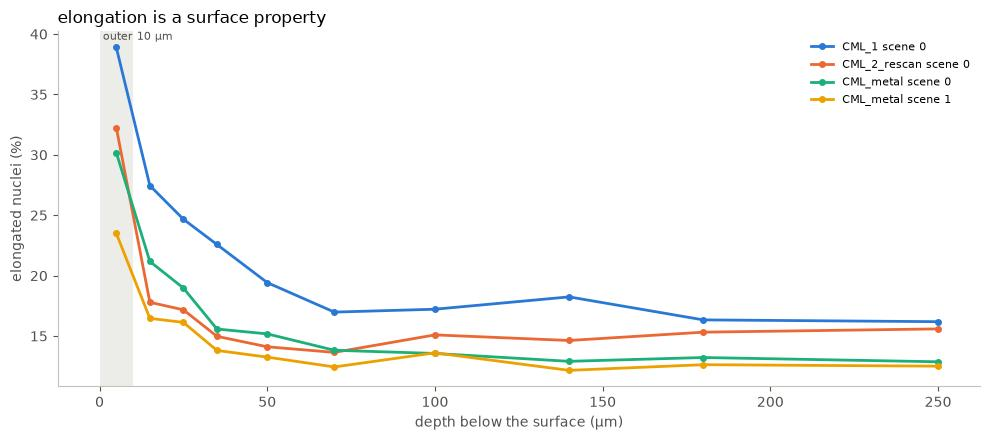

In [4]:
dp = M.depth_profile(df)
fig, ax = plt.subplots(figsize=(10, 4.5))
for (scene, d), col in zip(dp.groupby("scene"), E.SCENE_COLORS):
    ax.plot(d.mid_um, d["mean"], color=col, lw=2, marker="o", ms=4, label=scene)
ax.axvspan(0, 10, color="#c3c2b7", alpha=0.3, lw=0)
ax.text(1, ax.get_ylim()[1], "outer 10 µm", va="top", fontsize=8, color="#52514e")
ax.set_xlabel("depth below the surface (µm)"); ax.set_ylabel("elongated nuclei (%)")
ax.set_title("elongation is a surface property", loc="left"); ax.legend(fontsize=8, frameon=False)
plt.tight_layout(); plt.show()

## Random gallery: meninges (6 random windows per slide, 120 µm)

Window centres are random surface-meninges nuclei (seed 0), kept if the window holds ≥ 15 meningeal
nuclei and lies ≥ 300 µm from earlier draws. Meningeal nuclei at full strength, all others faded; the line
above each panel counts the meningeal nuclei.

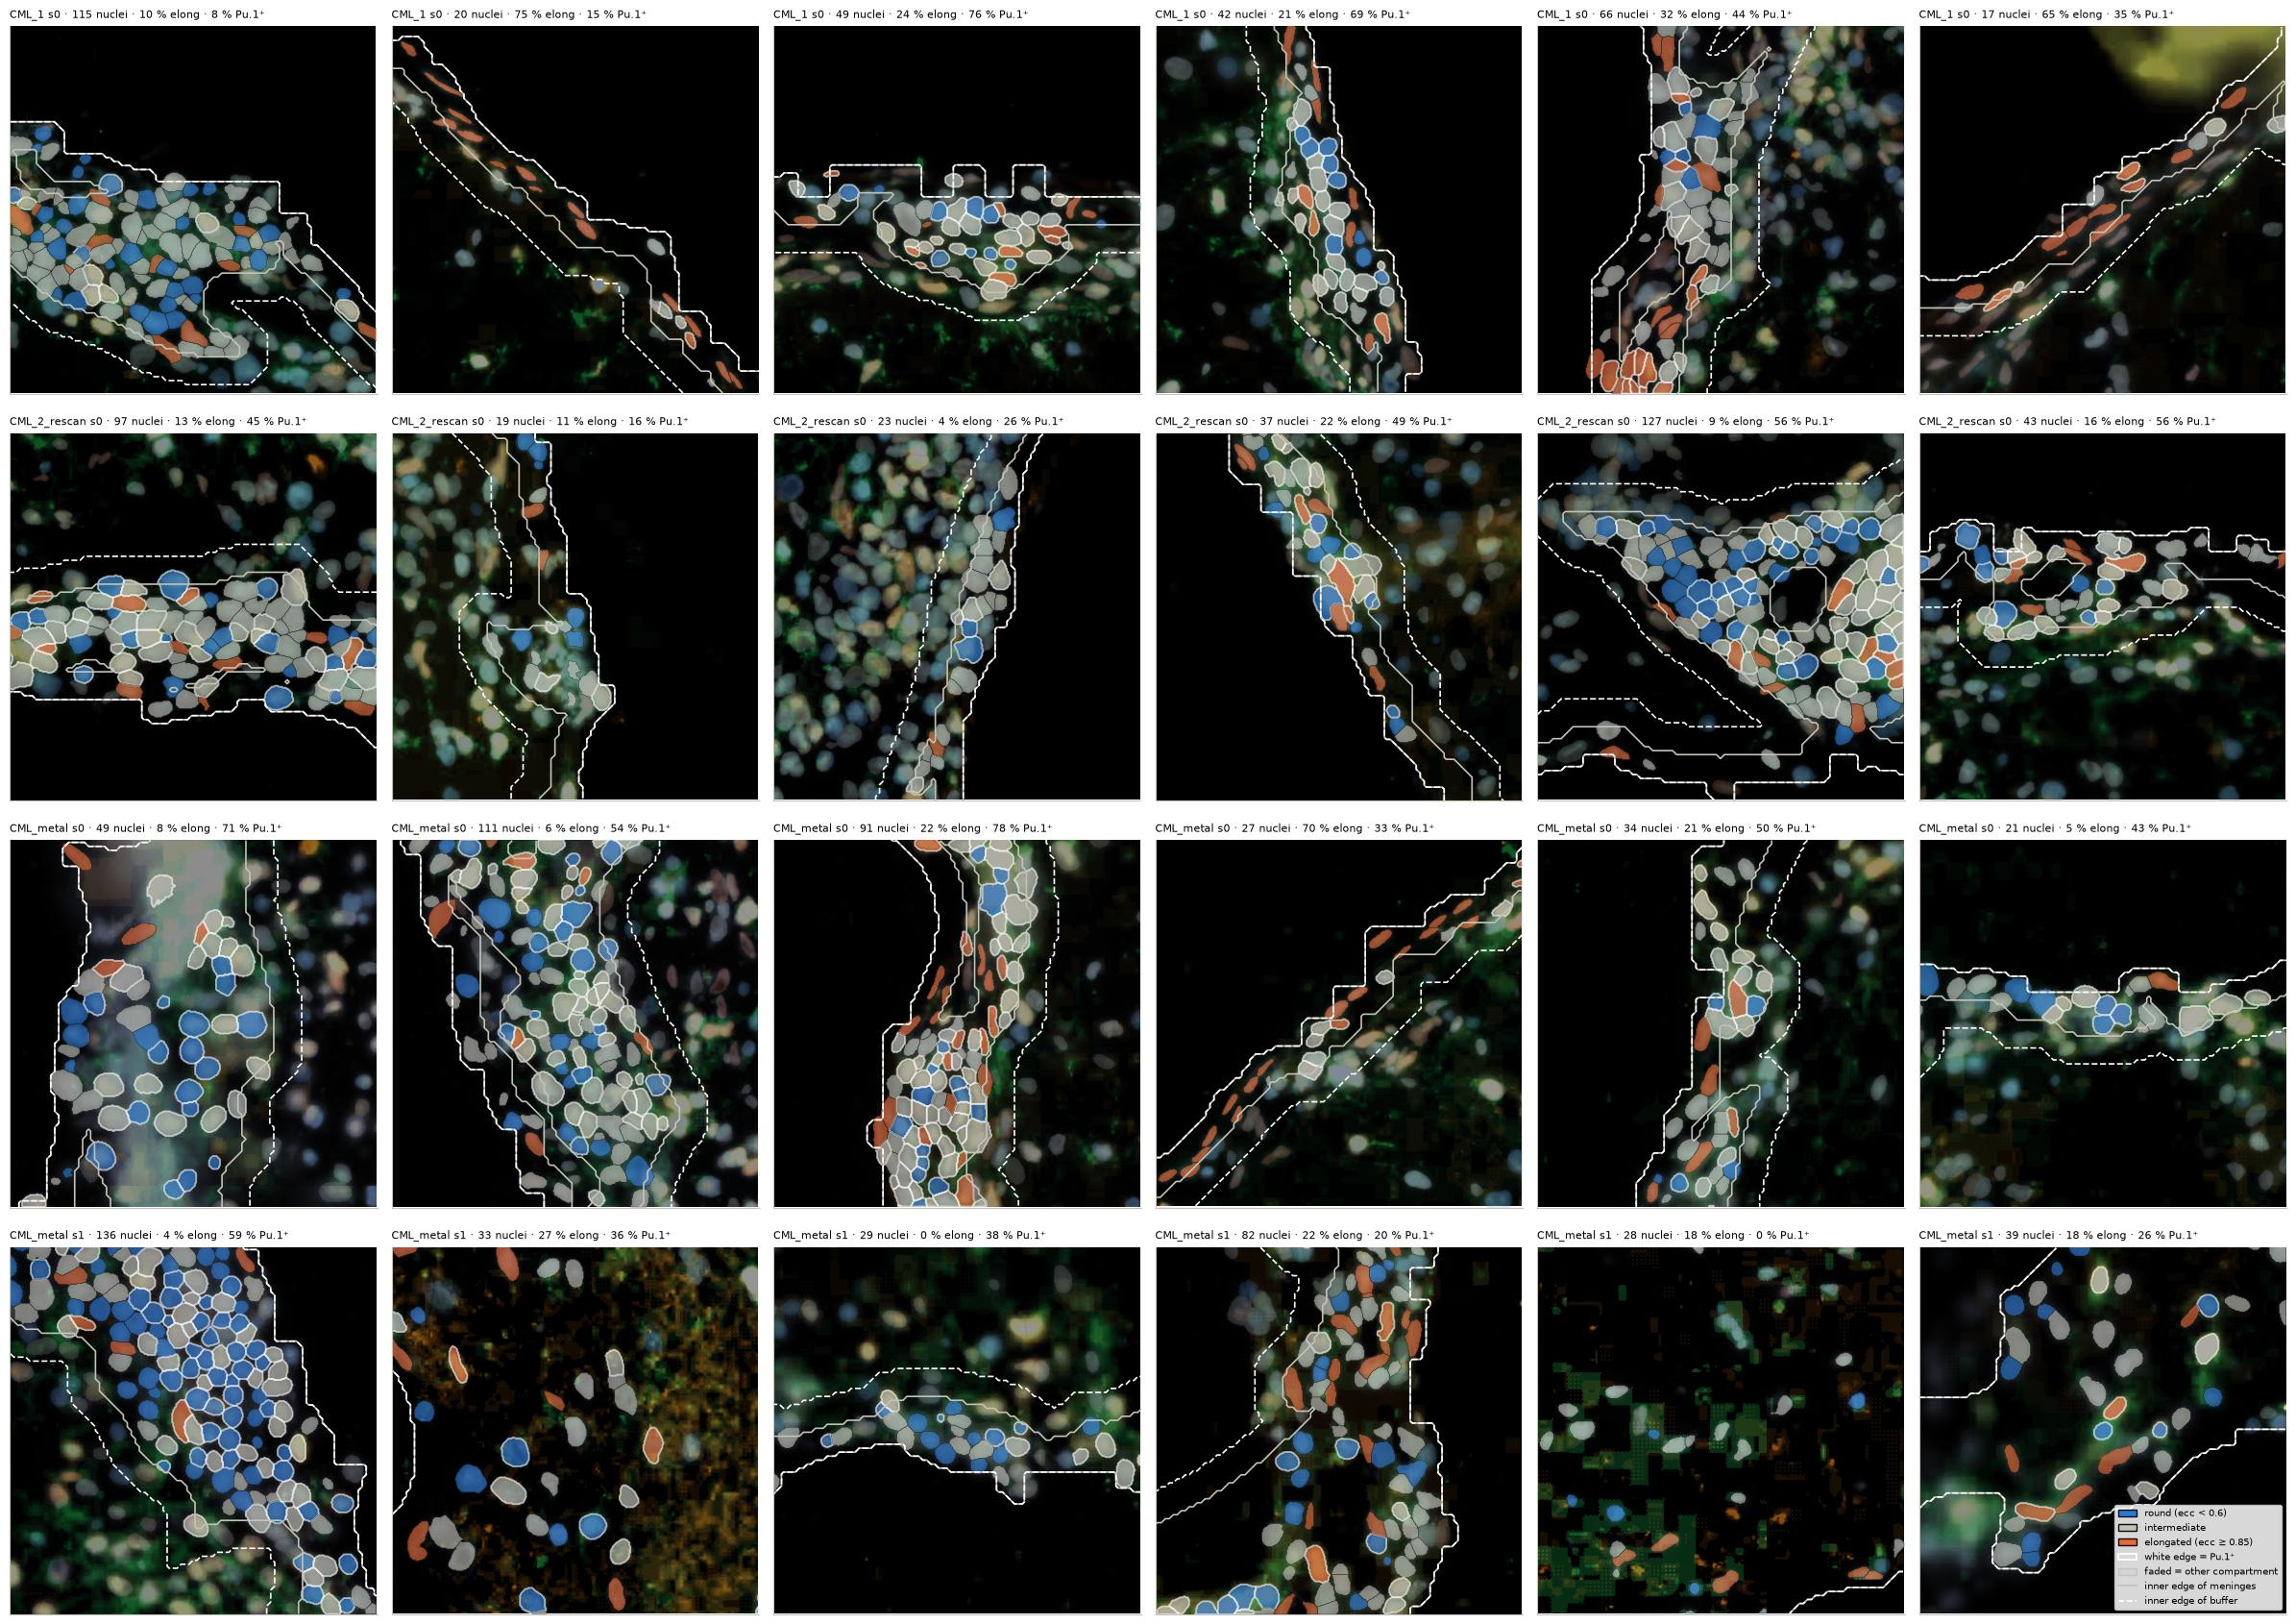

In [5]:
SIZE, N = 120, 6
comp_by_scene = {r.name: M.window_compartments(r.cells, E.compartment(r.cells)) for r in runs}
ref_share = (df[M.reference_compartment(df) == "parenchyma"].assign(el=lambda d: d.eccentricity >= M.ELONG_MIN)
             .groupby("scene")["el"].mean())
tally = []
def gallery(target, n, seed=0):
    rows = []
    for r in runs:
        for w in M.random_windows(r.cells, comp_by_scene[r.name], target, n, size_um=SIZE, seed=seed):
            rows.append((r, w))
    ncol = 6
    nrow = int(np.ceil(len(rows) / ncol))
    fig, axes = plt.subplots(nrow, ncol, figsize=(4 * ncol, 4.3 * nrow), squeeze=False)
    for ax, (r, (x, y)) in zip(axes.ravel(), rows):
        st = M.plot_nuclei(ax, r, r.cells, x, y, SIZE, comp=comp_by_scene[r.name], focus=target)
        ax.set_title(f"{r.name.replace(' scene ', ' s')} · {st['n_focus']} nuclei · {100 * st['elongated_focus']:.0f} % elong · {100 * st['pu1_focus']:.0f} % Pu.1⁺",
                     loc="left", fontsize=8)
        tally.append({"target": target, "scene": r.name, "x": x, "y": y, **st,
                      "slide_parenchyma_elongated": ref_share[r.name]})
    for ax in axes.ravel()[len(rows):]:
        ax.axis("off")
    M.class_legend(axes.ravel()[len(rows) - 1])
    plt.tight_layout(); plt.show()
gallery("meninges", N)

## Random gallery: distal parenchyma for comparison (3 random windows per slide)

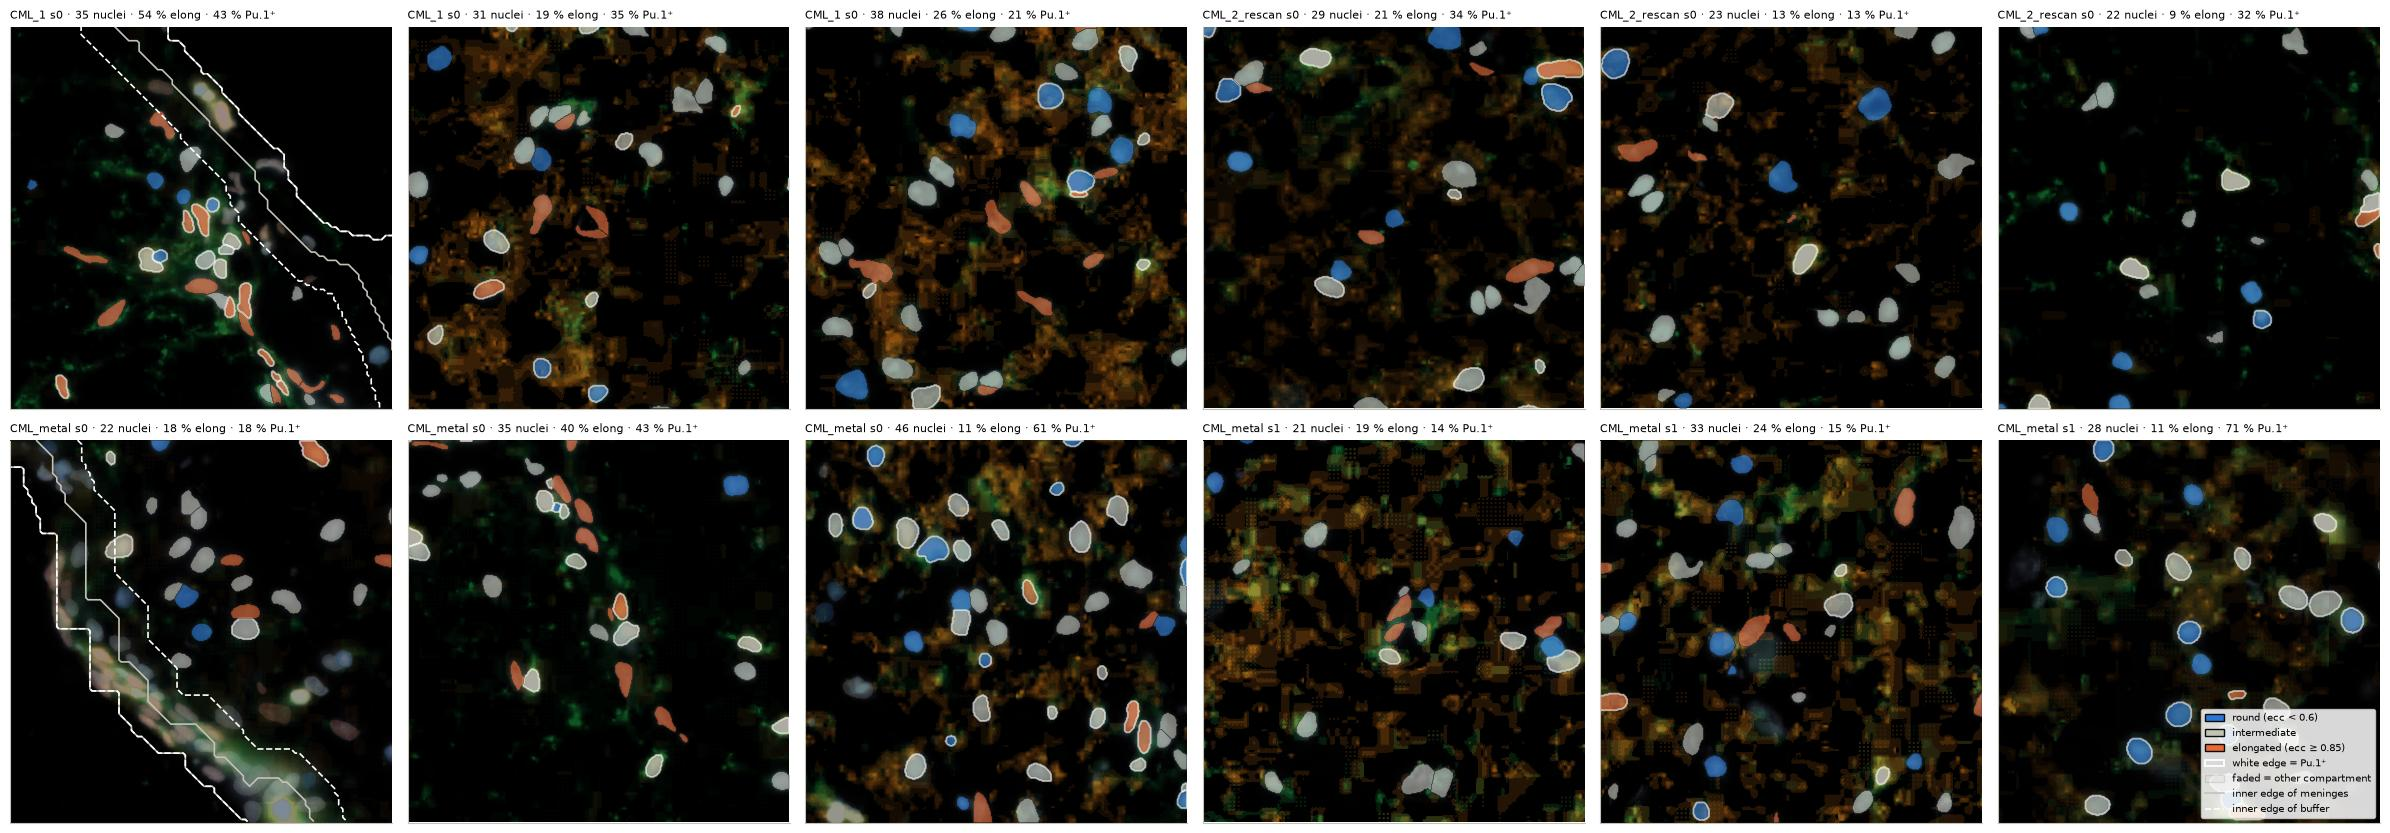

In [6]:
gallery("distal", 3)

## Tally: random windows vs their slide's parenchyma

In [7]:
t = pd.DataFrame(tally)
t["higher_than_parenchyma"] = t.elongated_focus > t.slide_parenchyma_elongated
display(t.groupby("target").agg(windows=("x", "size"), median_elongated=("elongated_focus", "median"),
                                 slide_parenchyma=("slide_parenchyma_elongated", "median"),
                                 windows_higher=("higher_than_parenchyma", "sum")).round(3))
display(t.round(3))

,windows,median_elongated,slide_parenchyma,windows_higher
target,,,,
distal,12,0.192,0.162,8
meninges,24,0.179,0.162,13


,target,scene,x,y,n_focus,n_other,elongated_focus,pu1_focus,slide_parenchyma_elongated,higher_than_parenchyma
0,meninges,CML_1 scene 0,6242.367,4019.643,115,42,0.096,0.078,0.165,False
1,meninges,CML_1 scene 0,6886.795,2277.638,20,15,0.750,0.150,0.165,True
2,meninges,CML_1 scene 0,3862.075,1515.290,49,49,0.245,0.755,0.165,True
3,meninges,CML_1 scene 0,4589.401,2257.242,42,54,0.214,0.690,0.165,True
4,meninges,CML_1 scene 0,5832.776,2478.364,66,117,0.318,0.439,0.165,True
5,meninges,CML_1 scene 0,1323.931,4282.655,17,33,0.647,0.353,0.165,True
6,meninges,CML_2_rescan scene 0,8726.817,3803.866,97,52,0.134,0.454,0.190,False
7,meninges,CML_2_rescan scene 0,10083.327,1947.705,19,58,0.105,0.158,0.190,False
8,meninges,CML_2_rescan scene 0,10078.601,2577.823,23,141,0.043,0.261,0.190,False
9,meninges,CML_2_rescan scene 0,786.187,8334.466,37,47,0.216,0.486,0.190,True


### Why single random windows disagree: the thin surface layer vs swollen meninges

One 120 µm window holds 20–130 meningeal nuclei – too few for a stable share (± ~8 points at 30 nuclei) –
and the meninges are not uniform. The section-level test below splits the meningeal nuclei by depth below
the surface: the thin outer layer against the deeper, swollen part.

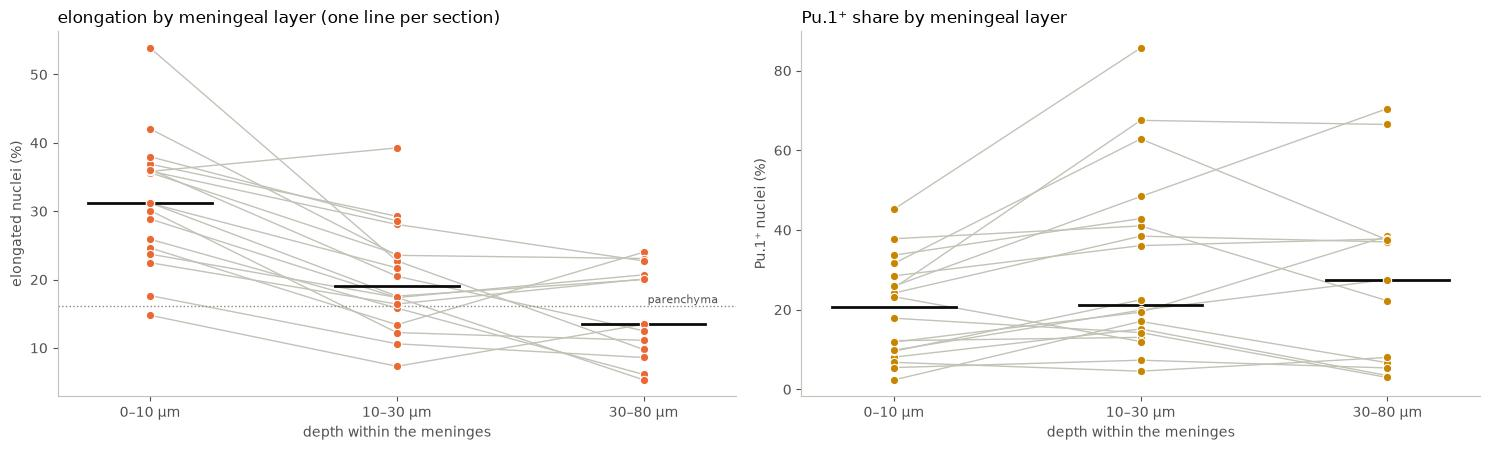

,outer layer vs,sections,median_delta_pp,sections_outer_higher,wilcoxon_p
0,10–30 µm,18,9.7621,17,0.0000
1,30–80 µm,13,13.1435,13,0.0002


,elongated %,Pu.1⁺ %
layer,,
0–10 µm,31.2,20.5
10–30 µm,19.0,21.2
30–80 µm,13.4,27.6


In [8]:
from scipy.stats import wilcoxon
lay = M.meninges_layers(df)
el = lay.pivot_table(index="section", columns="layer", values="el", observed=True)
pu = lay.pivot_table(index="section", columns="layer", values="pu1", observed=True)
cols = list(el.columns)
fig, axes = plt.subplots(1, 2, figsize=(15, 4.6))
for ax, tab, lab in ((axes[0], el, "elongated nuclei (%)"), (axes[1], pu, "Pu.1⁺ nuclei (%)")):
    x = np.arange(len(cols))
    for _, row in tab.iterrows():
        ax.plot(x, row.to_numpy(float), color="#c3c2b7", lw=1)
    for i, c in enumerate(cols):
        v = tab[c].dropna()
        ax.scatter(np.full(len(v), i), v, s=36, color="#eb6834" if tab is el else "#c98500", edgecolors="white", linewidths=0.8, zorder=3)
        ax.plot([i - 0.25, i + 0.25], [v.median()] * 2, color="#0b0b0b", lw=2)
    ax.set_xticks(x, cols); ax.set_xlabel("depth within the meninges"); ax.set_ylabel(lab)
axes[0].axhline(100 * ref_share.median(), color="#898781", lw=1, ls=":")
axes[0].text(len(cols) - 1, 100 * ref_share.median(), " parenchyma", va="bottom", fontsize=8, color="#52514e")
axes[0].set_title("elongation by meningeal layer (one line per section)", loc="left")
axes[1].set_title("Pu.1⁺ share by meningeal layer", loc="left")
plt.tight_layout(); plt.show()
rows = []
for c in cols[1:]:
    dd = (el[cols[0]] - el[c]).dropna()
    rows.append({"outer layer vs": c, "sections": len(dd), "median_delta_pp": dd.median(),
                 "sections_outer_higher": int((dd > 0).sum()), "wilcoxon_p": wilcoxon(dd).pvalue})
display(pd.DataFrame(rows).round(4))
display(pd.concat({"elongated %": el.median(), "Pu.1⁺ %": pu.median()}, axis=1).round(1))

## Reading

* **Reliable, at the right unit.** Pooled per section, meninges carry more elongated nuclei than their own
  parenchyma in 16 of 17 sections from 6 animals (+13 points, 95 % hierarchical-bootstrap CI ~10–17), and
  the effect survives every check – including the edge control: parenchyma right under the surface is
  not equally elongated, so this is not a cut-edge or squashing artefact.
* **It is the thin surface layer.** Split by depth, the outer ≤ 10 µm of the meninges is strongly
  elongated and ~80 % Pu.1⁻ (flattened nuclei along the pia – the best proxy here for meningeal cells),
  while deeper meninges fall back to parenchyma levels of elongation. Their Pu.1⁺ share varies a lot
  between sections (median ~25 %, up to 70–85 % where the meninges are swollen with infiltrate), so
  "deeper = infiltrate" holds only in the swollen sections. Single random windows mix the layers, which
  is why many do *not* beat the parenchyma – the tally shows that heterogeneity, it does not contradict
  the section-level result.
* Cell identity still needs a marker (fibroblast / leptomeningeal); this panel can only say *where* the
  elongated nuclei are.
* What this cannot establish: cell identity. The compartment mixes meningeal cells and infiltrate; a
  fibroblast / leptomeningeal marker would be needed to say *which* cells are elongated.